In [1]:
import numpy as np
import matplotlib.pyplot as plt

from control_functional_implementation import *

In [ ]:
np.random.seed(4198)
S_0, K, r, T, sig = 50, 50, 0.02, 1.0, 0.2

# Run on GPU if available. CPU may be prohibitively slow for large N.
N_values = np.array([100, 500, 1000, 5000, 10000, 50000, 100000])

se_values = []
for N in N_values:
    # Generate plain Monte samples of straddle option
    Z = np.random.randn(N)
    S_T = S_0 * np.exp((r - 0.5 * sig**2) * T + sig * np.sqrt(T) * Z)
    payoff = np.abs(S_T - K)
    discounted_payoff = np.exp(-r * T) * payoff
    se_plain = np.std(discounted_payoff, ddof=1) / np.sqrt(N)

    # Control Variate
    Y1 = S_T
    Y2 = S_T**2
    mu_Y1 = S_0 * np.exp(r * T)
    mu_Y2 = S_0**2 * np.exp(2 * r * T + sig**2 * T)
    ## Fit coefficients b1 and b2 using regression X ~ Y1 + Y2
    ones = np.ones(N)
    A = np.vstack([Y1, Y2, ones]).T
    b_opt, _, _, _ = np.linalg.lstsq(A, discounted_payoff, rcond=None)
    b1_opt, b2_opt = b_opt[0], b_opt[1]
    H_cv = discounted_payoff - b1_opt * (Y1 - mu_Y1) - b2_opt * (Y2 - mu_Y2)
    se_cv = np.std(H_cv, ddof=1) / np.sqrt(N)

    ## Control Functional
    X_cf = Z.reshape(-1, 1)
    Y_cf = discounted_payoff.reshape(-1, 1)
    cf_model = ControlFunctional(X_cf, Y_cf, eta=0.1, length_scale=0.25, decay_scale=1e-3)
    cf_model.fit(alpha=1e-3)
    cf_model.predict()
    se_cf = cf_model.std_err

    se_values.append((se_plain, se_cv, se_cf))



In [ ]:
# Print the values of SE
se_plain = np.array([se[0] for se in se_values])
se_cv = np.array([se[1] for se in se_values])
se_cf = np.array([se[2] for se in se_values])
for i, N in enumerate(N_values):
    print(f"N = {N}, plain SE: {se_plain[i]:.6f}, plain CV: {se_cv[i]:.6f}, plain CF: {se_cf[i]:.6f}")

N = 100, plain SE: 0.697089, plain CV: 0.283543, plain CF: 0.956504
N = 500, plain SE: 0.284676, plain CV: 0.242137, plain CF: 0.139558
N = 1000, plain SE: 0.199590, plain CV: 0.169790, plain CF: 0.043928
N = 5000, plain SE: 0.087979, plain CV: 0.076489, plain CF: 0.027245
N = 10000, plain SE: 0.062810, plain CV: 0.054558, plain CF: 0.012378
N = 50000, plain SE: 0.028535, plain CV: 0.024593, plain CF: 0.001628
N = 100000, plain SE: 0.020178, plain CV: 0.017425, plain CF: 0.001707


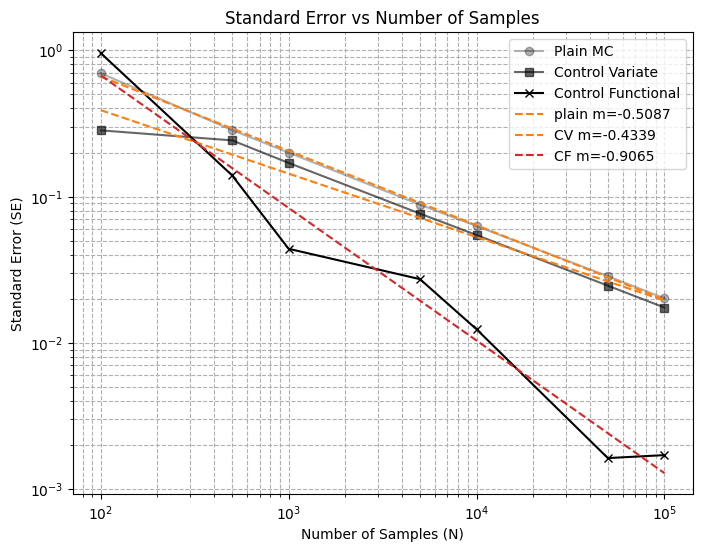

In [ ]:
# plot se values on log-log scale
plt.figure(figsize=(8, 6))

plt.loglog(N_values, se_plain, label="Plain MC", marker='o', color="black", alpha=0.3)
plt.loglog(N_values, se_cv, label="Control Variate", marker='s', color="black", alpha=0.6)
plt.loglog(N_values, se_cf, label="Control Functional", marker='x', color="black")

# Plot reference lines for O(1/sqrt(n))
n_ref = np.array(N_values)

m_plain, b_plain = np.polyfit(np.log10(n_ref), np.log10(se_plain), 1)
se_ref_plain = 10**b_plain * n_ref**m_plain
plt.loglog(n_ref, se_ref_plain, color='tab:orange', linestyle='--', label=f'plain m={m_plain:.4f}')

m_cv, b_cv = np.polyfit(np.log10(n_ref), np.log10(se_cv), 1)
se_ref_cv = 10**b_cv * n_ref**m_cv
plt.loglog(n_ref, se_ref_cv, color='tab:orange', linestyle='--', label=f'CV m={m_cv:.4f}')

m_cf, b_cf = np.polyfit(np.log10(n_ref), np.log10(se_cf), 1)
se_ref_cf = 10**b_cf * n_ref**m_cf
plt.loglog(n_ref, se_ref_cf, color='tab:red', linestyle='--', label=f'CF m={m_cf:.4f}')


plt.xlabel("Number of Samples (N)")
plt.ylabel("Standard Error (SE)")

plt.title("Standard Error vs Number of Samples")

plt.grid(True, which="both", ls="--")
plt.legend()

plt.savefig("assets/control-functional-se-vs-sample-size.png")

In [ ]:
# SE function.